Steel demand

In [230]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.optimize import curve_fit
import pandas_datareader.wb as wb
import statsmodels.api as sm
from scipy import stats
from dynamic_stock_model import DynamicStockModel

Load data

In [231]:
# Define base path
base_path = Path.cwd().parent

# Define folders
steel_folder = base_path / "data" / "raw" / "Steel"
gdp_folder = base_path / "data" / "raw" / "gdp"
pop_folder = base_path / "data" / "raw" / "population"

# Load historic steel data
steel_data = pd.read_excel(steel_folder / "steel.xlsx")

# Load historic product categories for steel data from 1900 to 2008
steel_shares = pd.read_csv(steel_folder / "steel_shares_1900_2008.csv")

# Load GDP data
historic_gdp_data = pd.read_csv(gdp_folder / "gdp_1960_2024.csv")
future_gdp_data = pd.read_csv(gdp_folder / "gdp_1980_2100.csv")

# Load population data
pop_data = pd.read_csv(pop_folder / "population.csv")

# Load future population data
future_pop_data = pd.read_csv(pop_folder / "future_population.csv")

C:\Users\ovid\AppData\Local\Temp\ipykernel_41280\1281377678.py:23: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  future_pop_data = pd.read_csv(pop_folder / "future_population.csv")


Clean GDP data

In [232]:
# Create dataframe for the years 1960 to 2024 with the columns "year" and "gdp"
historic_gdp = pd.DataFrame({
    "year": np.arange(1960, 2025),
    "gdp": None
})

# Melt wide format to long format
historic_gdp_data_long = historic_gdp_data.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="year",
    value_name="gdp"
)

historic_gdp_data_long["year"] = historic_gdp_data_long["year"].astype(int)

# Then fill in the historic dataframe
for index, row in historic_gdp.iterrows():
    year = row["year"]
    match = historic_gdp_data_long.loc[historic_gdp_data_long["year"] == year, "gdp"]
    if not match.empty:
        historic_gdp.at[index, "gdp"] = match.values[0]

# Create dataframe for the years 2025 to 2050 with the columns "year", "SSP1", "SSP2", "SSP3" "SSP5"
future_gdp = pd.DataFrame({
    "year": np.arange(2025, 2051),
    "SSP1": None,
    "SSP2": None,
    "SSP3": None,
    "SSP5": None
})

# Fill the future_gdp dataframe with corresponding GDP values from future_gdp_data
# The data has scenario columns "SSP1", "SSP2", "SSP3" and "SSP5" and the value is in the corresponding every 5th year column (2025, 2030, ..., 2050)
# The unit column has the value "billion USD_2017/yr"
for index, row in future_gdp.iterrows():
    year = row["year"]
    if year % 5 != 0:
        continue
    for ssp in ["SSP1", "SSP2", "SSP3", "SSP5"]:
        gdp_value = future_gdp_data.loc[(future_gdp_data["scenario"] == ssp) & (future_gdp_data["unit"] == "billion USD_2015/yr"), str(year)].values[0]
        future_gdp.at[index, ssp] = gdp_value

for col in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    future_gdp[col] = pd.to_numeric(future_gdp[col], errors='coerce')
    future_gdp[col] = future_gdp[col] * 1e9

# Scale future GDP to match historic at join point
correction = historic_gdp.loc[historic_gdp['year'] == 2024, 'gdp'].values[0] / \
             future_gdp.loc[future_gdp['year'] == 2025, 'SSP2'].values[0]

print(f"Correction factor: {correction:.4f}")

for col in ['SSP1', 'SSP2', 'SSP3', 'SSP5']:
    future_gdp[col] = future_gdp[col] * correction

#display(future_gdp)

Correction factor: 0.6486


Clean steel data

In [233]:
# Make copy of steel data for cleaning
steel_stock_data = steel_data.copy()

# Clean steel data, header of data is at index 1
steel_stock_data.columns = steel_data.iloc[1]
steel_stock_data = steel_stock_data.drop(index=[0, 1])

steel_stock_data = steel_stock_data.rename(columns={'total stock S': 'steel_stock',
                                                    'S - Vehicles': 'vehicles',
                                                    'S - Machinery': 'machinery',
                                                    'S - BC': 'BC',
                                                    'S - Appliances': 'appliances'
                                                    })

In [234]:
# Clean and filter for world total
pop_data = pop_data[['Year', 'Code', 'Population']].copy()

# Only keep world data, Entity = World
pop_data = pop_data[pop_data['Code'] == 'OWID_WRL']

# Drop the 'Code' column
pop_data = pop_data.drop(columns=['Code'])

# Rename columns
pop_data = pop_data.rename(columns={'Year': 'year', 'Population': 'population'})

# Only keep values from 1700 to 2008 based on "Year" column
pop_data = pop_data[(pop_data['year'] >= 1700) & (pop_data['year'] <= 2008)]

# Clean future population data, get population data from TPopulation1Jan based on "Time" column from 2009 to 2050 and "Location" column = World
future_pop_data = future_pop_data[['Time', 'Location', 'TPopulation1Jan']].copy()
future_pop_data = future_pop_data[future_pop_data['Location'] == 'World']
future_pop_data = future_pop_data[(future_pop_data['Time'] >= 2009) & (future_pop_data['Time'] <= 2050)]
future_pop_data = future_pop_data.rename(columns={'Time': 'year', 'TPopulation1Jan': 'population'})

,year,Location,population
35627,2009,World,6888343.594
35628,2010,World,6977189.237
35629,2011,World,7066275.059
35630,2012,World,7155572.472
35631,2013,World,7246832.497
35632,2014,World,7336754.673
35633,2015,World,7426477.815
35634,2016,World,7514505.928
35635,2017,World,7602603.123
35636,2018,World,7688632.785


Check correlation between steel and GDP growth

In [191]:
# Select only the columns "year" and "total stock S" and rename them to "year" and "steel_stock"
steel_stock_gdp = steel_stock_data[['year', 'steel_stock']].copy()

# Merge with historic GDP data
steel_stock_gdp = steel_stock_gdp.merge(historic_gdp[['year', 'gdp']], on='year', how='left')

steel_stock_gdp['steel_stock'] = pd.to_numeric(steel_stock_gdp['steel_stock'], errors='coerce')
steel_stock_gdp['gdp'] = pd.to_numeric(steel_stock_gdp['gdp'], errors='coerce')

# For correlation analysis, only use years where both exist (1960-2008)
steel_stock_corr = steel_stock_gdp.dropna(subset=['gdp', 'steel_stock'])

# Calculate log-differences on the overlapping period only
steel_stock_corr = steel_stock_corr.copy()
steel_stock_corr['stock_log_growth'] = np.log(steel_stock_corr['steel_stock']).diff()
steel_stock_corr['gdp_log_growth'] = np.log(steel_stock_corr['gdp']).diff()
steel_stock_corr = steel_stock_corr.dropna(subset=['stock_log_growth', 'gdp_log_growth'])

# Calculate log-differences for stock and GDP
steel_stock_gdp['stock_log_growth'] = np.log(steel_stock_gdp['steel_stock']).diff()
steel_stock_gdp['gdp_log_growth'] = np.log(steel_stock_gdp['gdp']).diff()

# Remove NaN values
steel_stock_gdp = steel_stock_gdp.dropna(subset=['stock_log_growth', 'gdp_log_growth'])

# Log-diff and pct change correlations
log_growth_corr = steel_stock_gdp['stock_log_growth'].corr(steel_stock_gdp['gdp_log_growth'])
pct_corr = steel_stock_gdp['steel_stock'].pct_change().corr(steel_stock_gdp['gdp'].pct_change())
print(f"Log-diff correlation: {log_growth_corr:.4f}")
print(f"Pct change correlation: {pct_corr:.4f}")

# Pearson correlation and p-value
r, p_value = stats.pearsonr(steel_stock_gdp['stock_log_growth'], steel_stock_gdp['gdp_log_growth'])
print(f"Correlation: {r:.4f}")
print(f"P-value: {p_value:.10f}")
print(f"N observations: {len(steel_stock_gdp)}")

# Leave-one-out analysis
for i in range(len(steel_stock_gdp)):
    mask = [j for j in range(len(steel_stock_gdp)) if j != i]
    r_loo, _ = stats.pearsonr(steel_stock_gdp.iloc[mask]['stock_log_growth'], steel_stock_gdp.iloc[mask]['gdp_log_growth'])
    year = steel_stock_gdp.index[i]
    print(f"Drop {year}: r = {r_loo:.4f}")

# Average GDP per unit of stock
avg_gdp = steel_stock_gdp["gdp"].mean()
avg_stock = steel_stock_gdp["steel_stock"].mean()
constant_avg = avg_gdp / avg_stock
print(constant_avg)

Log-diff correlation: 0.4796
Pct change correlation: 0.4828
Correlation: 0.4796
P-value: 0.0005627486
N observations: 48
Drop 261: r = 0.4792
Drop 262: r = 0.4700
Drop 263: r = 0.4746
Drop 264: r = 0.4606
Drop 265: r = 0.4624
Drop 266: r = 0.4639
Drop 267: r = 0.4855
Drop 268: r = 0.4572
Drop 269: r = 0.4526
Drop 270: r = 0.4915
Drop 271: r = 0.4804
Drop 272: r = 0.4593
Drop 273: r = 0.4400
Drop 274: r = 0.5419
Drop 275: r = 0.5600
Drop 276: r = 0.4680
Drop 277: r = 0.4791
Drop 278: r = 0.4782
Drop 279: r = 0.4781
Drop 280: r = 0.4988
Drop 281: r = 0.4888
Drop 282: r = 0.4835
Drop 283: r = 0.4738
Drop 284: r = 0.4900
Drop 285: r = 0.4808
Drop 286: r = 0.4782
Drop 287: r = 0.4814
Drop 288: r = 0.4883
Drop 289: r = 0.4805
Drop 290: r = 0.4743
Drop 291: r = 0.4622
Drop 292: r = 0.4652
Drop 293: r = 0.4621
Drop 294: r = 0.4817
Drop 295: r = 0.4780
Drop 296: r = 0.4860
Drop 297: r = 0.4915
Drop 298: r = 0.4734
Drop 299: r = 0.4873
Drop 300: r = 0.5054
Drop 301: r = 0.4621
Drop 302: r = 0.46

In [194]:
# Merge with steel stock
steel_stock_pop =  steel_stock_data[['year', 'steel_stock']].copy()

# Merge with historic GDP data
steel_stock_pop = steel_stock_pop.merge(pop_data[['year', 'population']], on='year', how='left')

steel_stock_pop['steel_stock'] = pd.to_numeric(steel_stock_pop['steel_stock'], errors='coerce')
steel_stock_pop['population'] = pd.to_numeric(steel_stock_pop['population'], errors='coerce')

# Only keep data from 1800 to 2008 based on "year" column
steel_stock_pop = steel_stock_pop[(steel_stock_pop['year'] >= 1700) & (steel_stock_pop['year'] <= 2008)]

# Log-diff correlation
steel_stock_pop['stock_log_growth'] = np.log(steel_stock_pop['steel_stock']).diff()
steel_stock_pop['pop_log_growth'] = np.log(steel_stock_pop['population']).diff()
steel_stock_pop = steel_stock_pop.dropna(subset=['stock_log_growth', 'pop_log_growth'])

log_growth_corr = steel_stock_pop['stock_log_growth'].corr(steel_stock_pop['pop_log_growth'])
pct_corr = steel_stock_pop['steel_stock'].pct_change().corr(steel_stock_pop['population'].pct_change())
print(f"Log-diff correlation: {log_growth_corr:.4f}")
print(f"Pct change correlation: {pct_corr:.4f}")

r, p_value = stats.pearsonr(steel_stock_pop['stock_log_growth'], steel_stock_pop['pop_log_growth'])
print(f"Correlation: {r:.4f}")
print(f"P-value: {p_value:.10f}")
print(f"N observations: {len(steel_stock_pop)}")

# Leave-one-out
for i in range(len(steel_stock_pop)):
    mask = [j for j in range(len(steel_stock_pop)) if j != i]
    r_loo, _ = stats.pearsonr(steel_stock_pop.iloc[mask]['stock_log_growth'], steel_stock_pop.iloc[mask]['pop_log_growth'])
    year = steel_stock_pop.index[i]
    print(f"Drop {year}: r = {r_loo:.4f}")

# Divide population to get capita
steel_stock_pop['capita'] = steel_stock_pop['population'] / 1000

# Find stock per capita in t/1000 person
steel_stock_pop['stock_per_capita'] = steel_stock_pop['steel_stock'] / (steel_stock_pop['capita'])

Log-diff correlation: -0.4656
Pct change correlation: -0.4629
Correlation: -0.4656
P-value: 0.0000000000
N observations: 208
Drop 101: r = -0.4622
Drop 102: r = -0.4622
Drop 103: r = -0.4625
Drop 104: r = -0.4625
Drop 105: r = -0.4629
Drop 106: r = -0.4628
Drop 107: r = -0.4625
Drop 108: r = -0.4625
Drop 109: r = -0.4620
Drop 110: r = -0.4634
Drop 111: r = -0.4637
Drop 112: r = -0.4642
Drop 113: r = -0.4646
Drop 114: r = -0.4646
Drop 115: r = -0.4647
Drop 116: r = -0.4655
Drop 117: r = -0.4653
Drop 118: r = -0.4652
Drop 119: r = -0.4651
Drop 120: r = -0.4650
Drop 121: r = -0.4646
Drop 122: r = -0.4645
Drop 123: r = -0.4646
Drop 124: r = -0.4646
Drop 125: r = -0.4647
Drop 126: r = -0.4647
Drop 127: r = -0.4649
Drop 128: r = -0.4649
Drop 129: r = -0.4644
Drop 130: r = -0.4642
Drop 131: r = -0.4644
Drop 132: r = -0.4646
Drop 133: r = -0.4642
Drop 134: r = -0.4638
Drop 135: r = -0.4631
Drop 136: r = -0.4635
Drop 137: r = -0.4634
Drop 138: r = -0.4635
Drop 139: r = -0.4635
Drop 140: r = -0.

In [195]:
# Define shares for steel products before 1900
shares_1900 = {
    "vehicles": 0.179350518036637,
    "machinery": 0.137017233159745,
    "BC": 0.604797209347797,
    "appliances": 0.078835039455821
}

categories = [
    "vehicles",
    "machinery",
    "BC",
    "appliances"
]

steel_stock_cat = steel_stock_data[['year', 'steel_stock']].copy()

# Extract total stock from 1700 to 1900 and apply constant shares
stock_pre1900 = steel_stock_cat[steel_stock_cat['year'] < 1900][['year', 'steel_stock']].copy()
for cat, share in shares_1900.items():
    stock_pre1900[f"stock_{cat}"] = stock_pre1900['steel_stock'] * share

# Extract total stock from 1900 to 2008 and apply year-specific shares
stock_post1900 = steel_stock_cat[(steel_stock_cat['year'] >= 1900) & (steel_stock_cat['year'] <= 2008)][['year', 'steel_stock']].copy()
stock_post1900 = stock_post1900.merge(steel_shares.reset_index(), on='year', how='left')
for cat in categories:
    stock_post1900[f"stock_{cat}"] = stock_post1900['steel_stock'] * stock_post1900[cat]

# Combine into single results dataframe
steel_stock_shares = pd.concat([stock_pre1900, stock_post1900], ignore_index=True)
steel_stock_shares = steel_stock_shares.sort_values('year').reset_index(drop=True)

# Keep columns year, steel_stock, stock_vehicles, stock_machinery, stock_BC, stock_appliances
steel_stock_shares = steel_stock_shares[['year', 'steel_stock', 'stock_vehicles', 'stock_machinery', 'stock_BC', 'stock_appliances']]

k (growth rate):      0.0208
k (historic):         0.0208
x0 (inflection year): 2044.4380


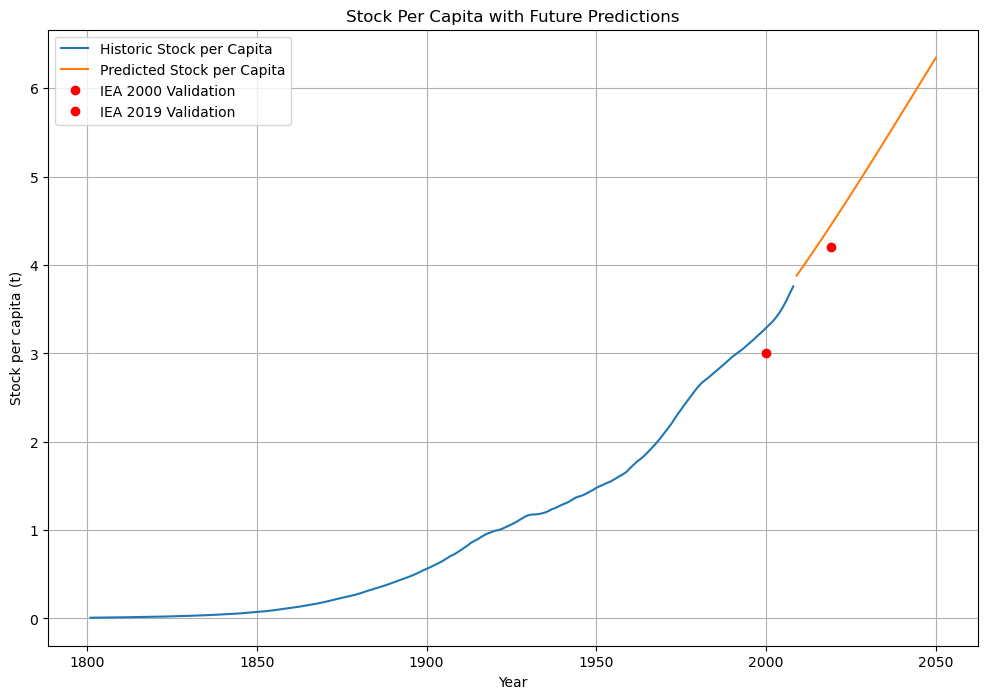

,year,stock_per_capita,type,total_stock,population
0,1801,0.008244,historic,8.132376e+06,9.864650e+08
1,1802,0.008658,historic,8.570310e+06,9.898648e+08
2,1803,0.009082,historic,9.021111e+06,9.933044e+08
3,1804,0.009529,historic,9.498778e+06,9.967843e+08
4,1805,0.009982,historic,9.985312e+06,1.000305e+09
...,...,...,...,...,...
245,2046,6.097570,predicted,5.770830e+10,9.464147e+06
246,2047,6.160010,predicted,5.859175e+10,9.511632e+06
247,2048,6.222416,predicted,5.947049e+10,9.557460e+06
248,2049,6.284773,predicted,6.034395e+10,9.601612e+06


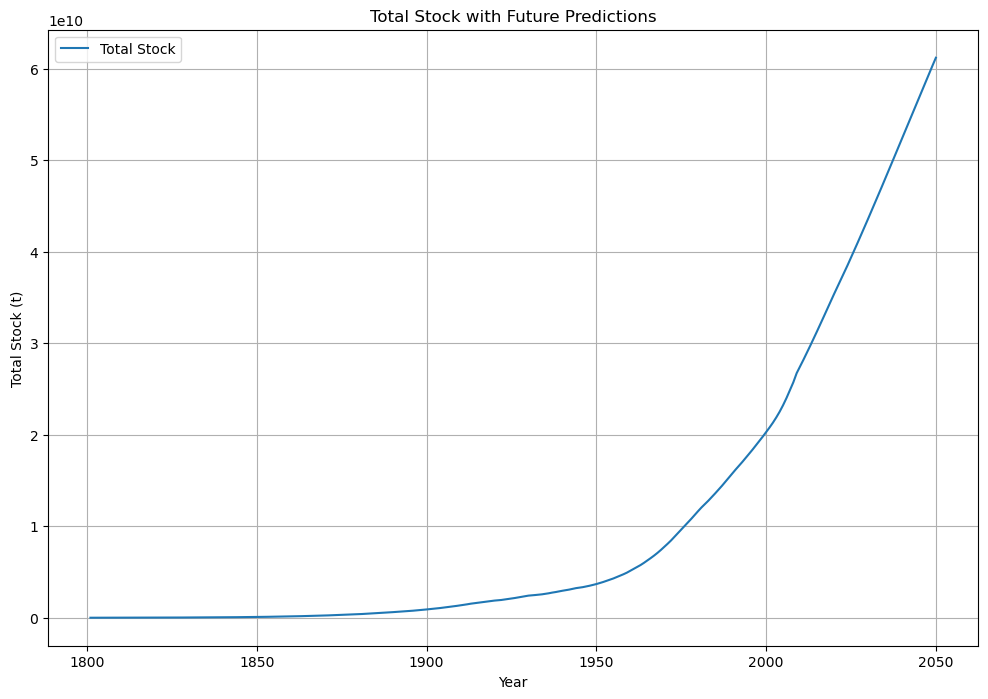

In [321]:
# Define future years for prediction
future_years = np.arange(2009, 2051)

# Fixed logistic function 
# (L for STEPS/SDS scenarios around 6.5t is 12)
# L = 8.5 to hit 2019 validation data (4.2t per capita, IEA)
def logistic_fixed_L(x, k, x0):
    L = 12  # fix L at desired value
    return L / (1 + np.exp(-k * (x - x0)))

# Predict future stock per capita using logistic regression
popt, _ = curve_fit(logistic_fixed_L, 
                    np.array(steel_stock_pop['year']), 
                    np.array(steel_stock_pop['stock_per_capita']),
                    p0=[0.05, 2060],
                    bounds=(
                        [0.01, 2020],   # lower bound of k and x0
                        [0.2,  2100]    # upper bound of k and x0
                    ),
                    maxfev=10000)

future_spc = logistic_fixed_L(future_years, *popt)


k, x0 = popt

# Growth rate for future stock per capita
print(f"k (growth rate):      {k:.4f}")
# Print growth rate for historic stock per capita
print(f"k (historic):         {popt[0]:.4f}")
# Inflection year
print(f"x0 (inflection year): {x0:.4f}")

# Plot future stock per capita predictions
plt.figure(figsize=(12, 8))
plt.plot(steel_stock_pop['year'], steel_stock_pop['stock_per_capita'], label='Historic Stock per Capita')
plt.plot(future_years, future_spc, label='Predicted Stock per Capita')
plt.plot(2000, 3, 'ro', label='IEA 2000 Validation')
plt.plot(2019, 4.2, 'ro', label='IEA 2019 Validation')
plt.xlabel('Year')
plt.ylabel('Stock per capita (t)')
plt.title('Stock Per Capita with Future Predictions')
plt.legend()
plt.grid()
plt.show()

# Combine historic and future stock per capita into one dataframe
stock_per_capita_df = pd.DataFrame({
    'year': np.concatenate([steel_stock_pop['year'], future_years]),
    'stock_per_capita': np.concatenate([steel_stock_pop['stock_per_capita'], future_spc]),
    'type': ['historic'] * len(steel_stock_pop) + ['predicted'] * len(future_years)
})

# Use predicted stock per capita and future population data to calculate total future stock
future_stock = future_spc * future_pop_data['population'].values

# Add total stock to the dataframe
stock_per_capita_df['total_stock'] = np.concatenate([steel_stock_pop['steel_stock'], future_stock]) * 1000  # convert from t/1000 person to t

# Add future population data from 2009 to 2050 in the dataframe
stock_per_capita_df['population'] = np.concatenate([steel_stock_pop['population'], future_pop_data['population']])

display(stock_per_capita_df)

# Plot total stock over time
plt.figure(figsize=(12, 8))
plt.plot(stock_per_capita_df['year'], stock_per_capita_df['total_stock'], label='Total Stock')
plt.xlabel('Year')
plt.ylabel('Total Stock (t)')
plt.title('Total Stock with Future Predictions')
plt.legend()
plt.grid()
plt.show()

In [322]:
# Define shares for steel products before 1900
shares_1900 = {
    "vehicles": 0.179350518036637,
    "machinery": 0.137017233159745,
    "BC": 0.604797209347797,
    "appliances": 0.078835039455821
}

steel_stock_cat2 = stock_per_capita_df[['year', 'total_stock']].copy()

# Extract total stock from 1700 to 1900 and apply constant shares
stock_pre1900 = steel_stock_cat2[steel_stock_cat2['year'] < 1900][['year', 'total_stock']].copy()
for cat, share in shares_1900.items():
    stock_pre1900[f"stock_{cat}"] = stock_pre1900['total_stock'] * share

# Extract total stock from 1900 to 2008 and apply year-specific shares
stock_post1900 = steel_stock_cat2[(steel_stock_cat2['year'] >= 1900) & (steel_stock_cat2['year'] <= 2008)][['year', 'total_stock']].copy()
stock_post1900 = stock_post1900.merge(steel_shares.reset_index(), on='year', how='left')
for cat in categories:
    stock_post1900[f"stock_{cat}"] = stock_post1900['total_stock'] * stock_post1900[cat]

# For future years, apply 2008 shares as constant shares
future_shares = steel_shares[steel_shares['year'] == 2008][categories].iloc[0]
future_stock_cat = stock_per_capita_df[stock_per_capita_df['year'] > 2008][['year', 'total_stock']].copy()
for cat in categories:
    future_stock_cat[f"stock_{cat}"] = future_stock_cat['total_stock'] * future_shares[cat]

# Combine into single results dataframe
steel_stock_shares = pd.concat([stock_pre1900, stock_post1900, future_stock_cat], ignore_index=True)
steel_stock_shares = steel_stock_shares.sort_values('year').reset_index(drop=True)

# Keep columns year, steel_stock, stock_vehicles, stock_machinery, stock_BC, stock_appliances
steel_stock_shares = steel_stock_shares[['year', 'total_stock', 'stock_vehicles', 'stock_machinery', 'stock_BC', 'stock_appliances']]

In [323]:
# Define timeframe for the combined historic and future data
t = np.arange(1801, 2051)

# Define lifetimes
lt_vehicles = {
    "Type": "LogNormal",
    "Mean": np.full(len(t), 15),
    "StdDev": np.full(len(t), 5)
}
    
lt_machinery = {
    "Type": "LogNormal",
    "Mean": np.full(len(t), 20),
    "StdDev": np.full(len(t), 8)
}

lt_bc = {
    "Type": "Normal",
    "Mean": np.full(len(t), 70),
    "StdDev": np.full(len(t), 25)
}

lt_appliances = {
    "Type": "LogNormal",
    "Mean": np.full(len(t), 8),
    "StdDev": np.full(len(t), 5)
}

In [324]:
# Logistic regression function 
def logistic(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

# Make a function based on the method for s_vehicles above so it will do it for all columns in steel_stock_shares
# Add initial guess to the function based on the data, K can be the max value of the stock share, r can be 0.1 and t0 can be the year where the stock share is half of the max value
def fit_logistic_and_apply(t, stock_data):
    # Initial guess for the parameters
    K_guess = np.max(stock_data)
    r_guess = 0.1
    t0_guess = t[np.argmax(stock_data >= K_guess / 2)]
    
    popt, _ = curve_fit(logistic, np.array(steel_stock_shares['year']), stock_data, p0=(K_guess, r_guess, t0_guess))
    K_fit, r_fit, t0_fit = popt
    print(f"Fitted parameters: K={K_fit:.2e}, r={r_fit:.4f}, t0={t0_fit:.1f}")
    return logistic(t, K_fit, r_fit, t0_fit)

Fitted parameters: K=1.37e+10, r=0.0313, t0=2043.9
Fitted parameters: K=1.28e+10, r=0.0453, t0=2025.8
Fitted parameters: K=6.49e+10, r=0.0367, t0=2035.7
Fitted parameters: K=6.39e+09, r=0.0304, t0=2050.5


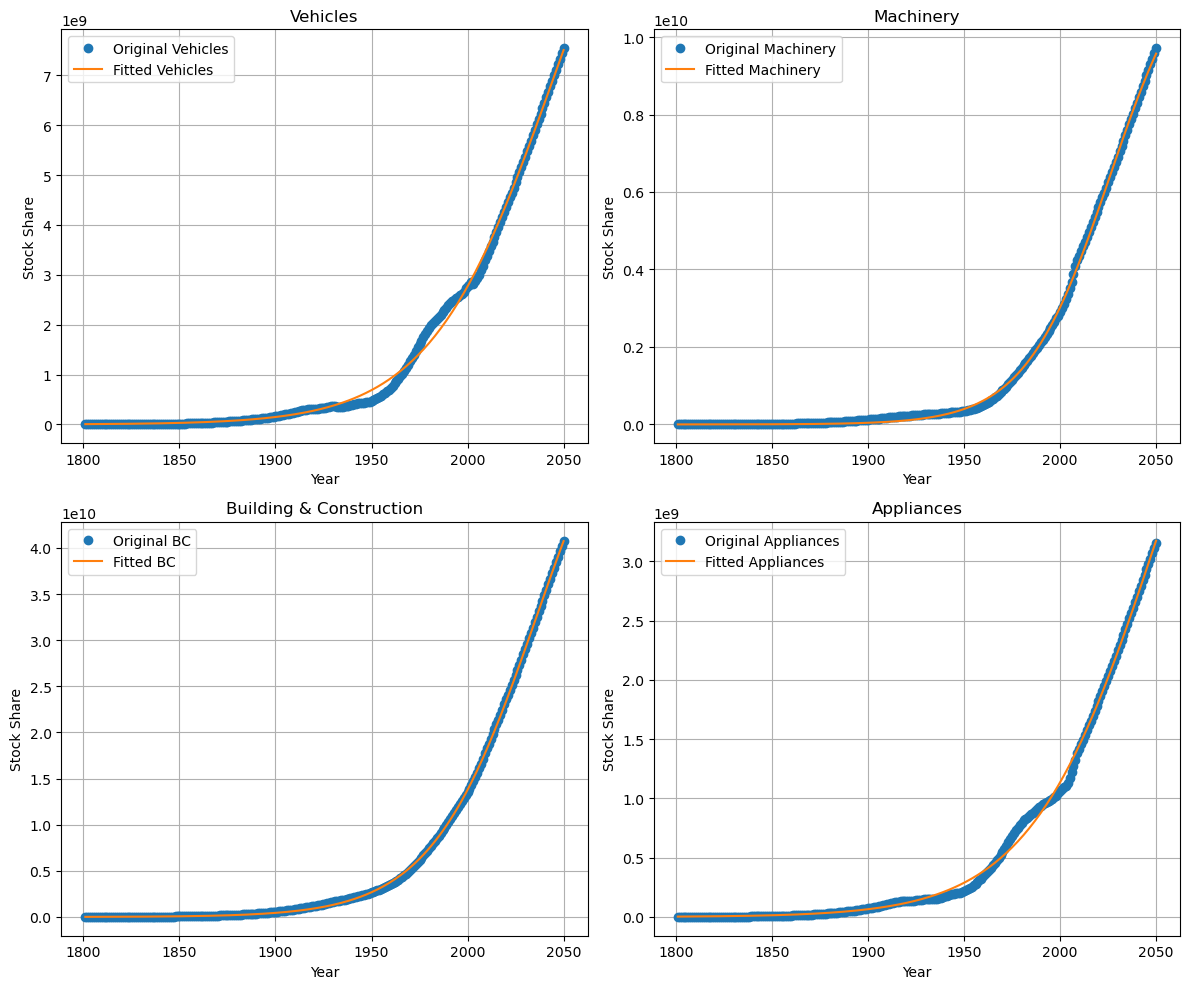

In [325]:
# Use function for all categories
s_vehicles = fit_logistic_and_apply(t, np.array(steel_stock_shares['stock_vehicles']))
s_machinery = fit_logistic_and_apply(t, np.array(steel_stock_shares['stock_machinery']))
s_bc = fit_logistic_and_apply(t, np.array(steel_stock_shares['stock_BC']))
s_appliances = fit_logistic_and_apply(t, np.array(steel_stock_shares['stock_appliances']))

# Plot the original shares and the fitted shares for all categories in subplots. this includes vehicles, machinery, BC and appliances. The x-axis is the year and the y-axis is the stock share. Include legends and grid for each subplot.
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].plot(t, steel_stock_shares['stock_vehicles'], 'o', label='Original Vehicles')
axs[0, 0].plot(t, s_vehicles, '-', label='Fitted Vehicles')
axs[0, 0].set_title('Vehicles')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Stock Share')
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].plot(t, steel_stock_shares['stock_machinery'], 'o', label='Original Machinery')
axs[0, 1].plot(t, s_machinery, '-', label='Fitted Machinery')
axs[0, 1].set_title('Machinery')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Stock Share')
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 0].plot(t, steel_stock_shares['stock_BC'], 'o', label='Original BC')
axs[1, 0].plot(t, s_bc, '-', label='Fitted BC')
axs[1, 0].set_title('Building & Construction')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Stock Share')
axs[1, 0].legend()
axs[1, 0].grid()

axs[1, 1].plot(t, steel_stock_shares['stock_appliances'], 'o', label='Original Appliances')
axs[1, 1].plot(t, s_appliances, '-', label='Fitted Appliances')
axs[1, 1].set_title('Appliances')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Stock Share')
axs[1, 1].legend()
axs[1, 1].grid()
plt.tight_layout()
plt.show()

In [326]:
# Run DSM
dsm = DynamicStockModel(
    t=t,
    s=s_vehicles,
    lt=lt_vehicles
)

s_c, o_c, i = dsm.compute_stock_driven_model(NegativeInflowCorrect = False)

#Compute outflow by cohort from stock by cohort.
o_c = dsm.compute_o_c_from_s_c()

#Determine total outflow as row sum of cohort-specific outflow.
o = dsm.compute_outflow_total()

#Determine stock change from time series for stock. Formula: stock_change(t) = stock(t) - stock(t-1).
stock_change = dsm.compute_stock_change()

# Make the dsm run into a function so it can take stock data and lifetime data for all categories
def run_dsm(t, s, lt):
    dsm = DynamicStockModel(
        t=t,
        s=s,
        lt=lt
    )
    s_c, o_c, i = dsm.compute_stock_driven_model(NegativeInflowCorrect = False)
    o_c = dsm.compute_o_c_from_s_c()
    o = dsm.compute_outflow_total()
    stock_change = dsm.compute_stock_change()
    return s_c, o_c, o, stock_change, i

# Run DSM for all categories
s_c_vehicles, o_c_vehicles, o_vehicles, stock_change_vehicles, i_vehicles = run_dsm(t, s_vehicles, lt_vehicles)
s_c_machinery, o_c_machinery, o_machinery, stock_change_machinery, i_machinery = run_dsm(t, s_machinery, lt_machinery)
s_c_bc, o_c_bc, o_bc, stock_change_bc, i_bc = run_dsm(t, s_bc, lt_bc)
s_c_appliances, o_c_appliances, o_appliances, stock_change_appliances, i_appliances = run_dsm(t, s_appliances, lt_appliances)

In [327]:
# Store all results from all categories in a dataframe. This includes vehicles, machinery, BC and appliances. The columns are "year", "stock", "inflow", "outflow" and "stock change" for each category, e.g. "stock_vehicles", "inflow_vehicles", etc.
results_vehicles = pd.DataFrame({
    'Year': t,
    'stock_vehicles': s_vehicles,
    'inflow_vehicles': i_vehicles,
    'outflow_vehicles': o_vehicles,
    'stock_change_vehicles': stock_change_vehicles
})

results_machinery = pd.DataFrame({
    'Year': t,
    'stock_machinery': s_machinery,
    'inflow_machinery': i_machinery,
    'outflow_machinery': o_machinery,
    'stock_change_machinery': stock_change_machinery
})

results_bc = pd.DataFrame({
    'Year': t,
    'stock_bc': s_bc,
    'inflow_bc': i_bc,
    'outflow_bc': o_bc,
    'stock_change_bc': stock_change_bc
})

results_appliances = pd.DataFrame({
    'Year': t,
    'stock_appliances': s_appliances,
    'inflow_appliances': i_appliances,
    'outflow_appliances': o_appliances,
    'stock_change_appliances': stock_change_appliances
})

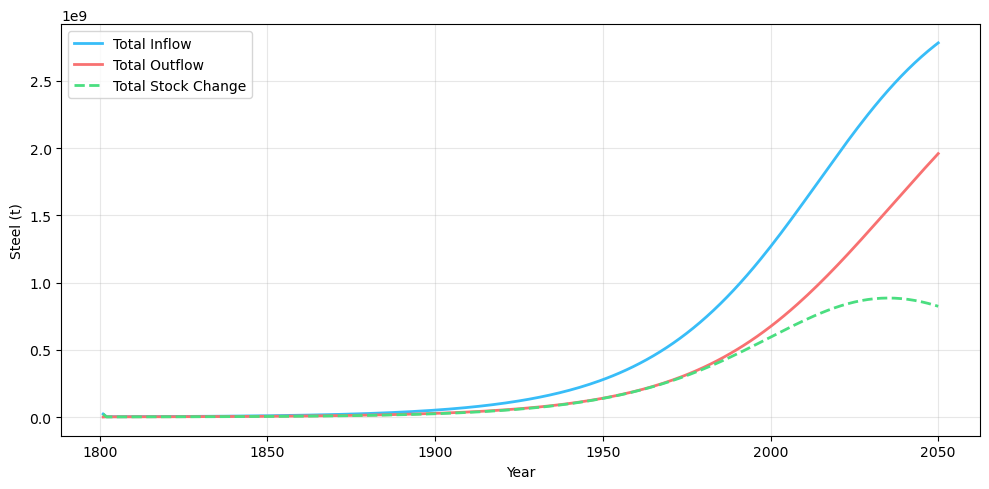

In [329]:
# Merge all dataframes on Year
results = results_vehicles.merge(results_machinery, on='Year') \
                          .merge(results_bc, on='Year') \
                          .merge(results_appliances, on='Year')

# Sum across categories
results['total_inflow']       = results['inflow_vehicles']       + results['inflow_machinery']       + results['inflow_bc']       + results['inflow_appliances']
results['total_outflow']      = results['outflow_vehicles']      + results['outflow_machinery']      + results['outflow_bc']      + results['outflow_appliances']
results['total_stock_change'] = results['stock_change_vehicles'] + results['stock_change_machinery'] + results['stock_change_bc'] + results['stock_change_appliances']

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(results['Year'], results['total_inflow'],       label='Total Inflow',        color='#38bdf8', linewidth=2)
ax.plot(results['Year'], results['total_outflow'],      label='Total Outflow',       color='#f87171', linewidth=2)
ax.plot(results['Year'], results['total_stock_change'], label='Total Stock Change',  color='#4ade80', linewidth=2, linestyle='--')

ax.set_xlabel('Year')
ax.set_ylabel('Steel (t)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

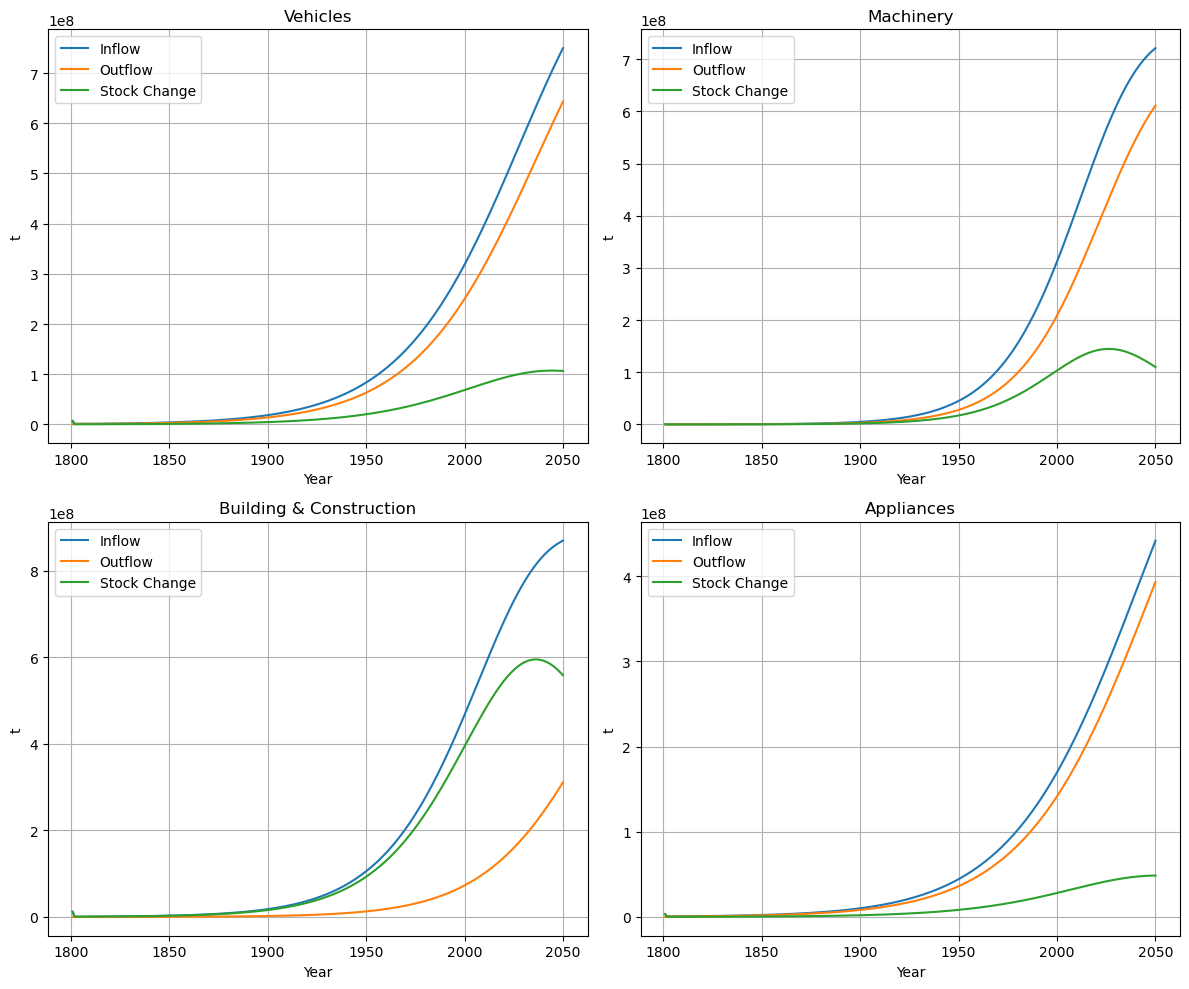

In [330]:
# Plot inflow, outflow and stock change for each category in subplots
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(results_vehicles['Year'], results_vehicles['inflow_vehicles'], label='Inflow')
plt.plot(results_vehicles['Year'], results_vehicles['outflow_vehicles'], label='Outflow')
plt.plot(results_vehicles['Year'], results_vehicles['stock_change_vehicles'], label='Stock Change')
plt.title('Vehicles')
plt.xlabel('Year')
plt.ylabel('t')
plt.legend()
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(results_machinery['Year'], results_machinery['inflow_machinery'], label='Inflow')
plt.plot(results_machinery['Year'], results_machinery['outflow_machinery'], label='Outflow')
plt.plot(results_machinery['Year'], results_machinery['stock_change_machinery'], label='Stock Change')
plt.title('Machinery')
plt.xlabel('Year')
plt.ylabel('t')
plt.legend()
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(results_bc['Year'], results_bc['inflow_bc'], label='Inflow')
plt.plot(results_bc['Year'], results_bc['outflow_bc'], label='Outflow')
plt.plot(results_bc['Year'], results_bc['stock_change_bc'], label='Stock Change')
plt.title('Building & Construction')
plt.xlabel('Year')
plt.ylabel('t')
plt.legend()
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(results_appliances['Year'], results_appliances['inflow_appliances'], label='Inflow')
plt.plot(results_appliances['Year'], results_appliances['outflow_appliances'], label='Outflow')
plt.plot(results_appliances['Year'], results_appliances['stock_change_appliances'], label='Stock Change')
plt.title('Appliances')
plt.xlabel('Year')
plt.ylabel('t')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [331]:
# Combine inflow from categories to calculate total inflow from 2022 to 2050
total_inflow = results_vehicles['inflow_vehicles'] + results_machinery['inflow_machinery'] + results_bc['inflow_bc'] + results_appliances['inflow_appliances']
total_inflow_future = total_inflow[results_vehicles['Year'] >= 2022]

# Interpolate for shares of steel production from 2022 to 2050
future_years_steel = np.arange(2022, 2051)

# Anchor points (sms-group source)
BF_2022,  BF_2050  = 72.0, 40.0
DRI_2022, DRI_2050 = 6.0,  20.0
EAF_2022, EAF_2050 = 22.0, 40.0

# Conversion factors for DRI and BF (H2 per ton of crude steel), I think I will leave this constant
DRI_conversion = 54/1000    #hydrogen need for DRI production, 54 kg H2 / t (up to 62)
BF_conversion = 29/1000     #hydrogen need for BF production, 29 kg H2 / t (up to 34)

# Linear interpolation
BF  = np.interp(future_years_steel, [2022, 2050], [BF_2022,  BF_2050])
DRI = np.interp(future_years_steel, [2022, 2050], [DRI_2022, DRI_2050])
EAF = np.interp(future_years_steel, [2022, 2050], [EAF_2022, EAF_2050])

# Store shares in total_inflow_future dataframe
total_inflow_future = pd.DataFrame({
    'Year': future_years_steel,
    'Total Inflow': total_inflow_future.values,
    'BF Share': BF,
    'DRI Share': DRI,
    'EAF Share': EAF
})

# Calculate inflow per production route and store in dataframe yearly values
total_inflow_future['BF Inflow'] = total_inflow_future['Total Inflow'] * total_inflow_future['BF Share'] / 100
total_inflow_future['DRI Inflow'] = total_inflow_future['Total Inflow'] * total_inflow_future['DRI Share'] / 100
total_inflow_future['EAF Inflow'] = total_inflow_future['Total Inflow'] * total_inflow_future['EAF Share'] / 100

# Calculate hydrogen requirement for DRI and BF with conversion factors
total_inflow_future['DRI H2'] = total_inflow_future['DRI Inflow'] * DRI_conversion
total_inflow_future['BF H2'] = total_inflow_future['BF Inflow'] * BF_conversion

DRI_hydrogen_need = np.array(total_inflow_future['DRI H2'])
BF_hydrogen_need = np.array(total_inflow_future['BF H2'])

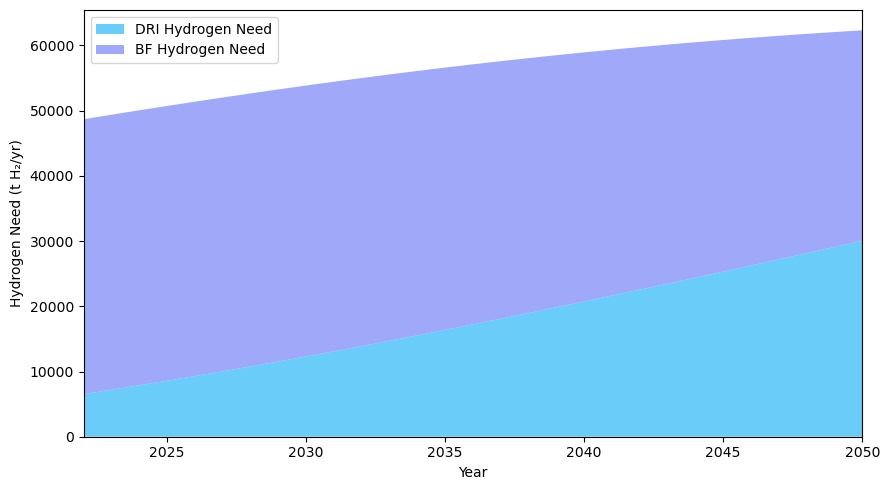

In [304]:
# Plot hydrogen need for DRI and BF production over time in a stacked area plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.stackplot(future_years_steel, DRI_hydrogen_need, BF_hydrogen_need, labels=["DRI Hydrogen Need", "BF Hydrogen Need"],
             colors=["#38bdf8", "#818cf8"], alpha=0.75)

ax.set_xlabel("Year")
ax.set_ylabel("Hydrogen Need (t H₂/yr)")
ax.legend(loc="upper left")
ax.set_xlim(future_years_steel[0], future_years_steel[-1])

plt.tight_layout()
plt.show()

In [332]:
# Total hydrogen demand in the world scenario M-SSP2
world_h2_demand = pd.DataFrame({
    "Year": [2025, 2030, 2035, 2040, 2045, 2050],
    "Value (EJ)": [0.654738, 1.811173, 3.724616, 6.534135, 9.453182, 12.765824]
})

# Convert EJ to tons of hydrogen
# 1 EJ = 1e18 J, 1 MWh = 3.6e6 J, so 1 EJ = 2.778e11 MWh
# If 1 t H2 = 33.3 MWh, then 1 EJ = 2.778e11 / 33.3 t H2
world_h2_demand['Value (t H2)'] = (world_h2_demand['Value (EJ)'] * 1e18) / (3.6e6 * 33.3)

# Filter steel hydrogen need for years 2025-2050 and interpolate for all years
steel_h2_yearly = total_inflow_future[total_inflow_future['Year'] >= 2025][['Year', 'DRI H2', 'BF H2']].copy()
steel_h2_yearly['Total H2 Need'] = steel_h2_yearly['DRI H2'] + steel_h2_yearly['BF H2']

# Merge with hydrogen demand (2025-2050 for which we have REMIND data)
comparison = world_h2_demand.merge(steel_h2_yearly, left_on='Year', right_on='Year', how='left')

# Calculate steel hydrogen as percentage of total hydrogen demand
comparison['Steel H2 % of Total'] = (comparison['Total H2 Need'] / comparison['Value (t H2)']) * 100

print(comparison[['Year', 'Value (t H2)', 'Total H2 Need', 'Steel H2 % of Total']])

   Year  Value (t H2)  Total H2 Need  Steel H2 % of Total
0  2025  5.461612e+09   5.071568e+07             0.928584
1  2030  1.510822e+10   5.384788e+07             0.356415
2  2035  3.106954e+10   5.660052e+07             0.182174
3  2040  5.450563e+10   5.893300e+07             0.108123
4  2045  7.885537e+10   6.083319e+07             0.077145
5  2050  1.064884e+11   6.231455e+07             0.058518
